# Recommender system with Surprise (MF)


reference: https://www.jiristodulka.com/post/recsys_cf/
https://predictivehacks.com/how-to-run-recommender-systems-in-python/




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from collections import defaultdict #data colector

#Surprise: https://surprise.readthedocs.io/en/stable/
import pandas as pd
import numpy as np
from sklearn.decomposition import NMF
from scipy import sparse

#read model
import pickle

# memory clear
import gc

np.random.seed(42) # replicating results

## Functions for sparse matrix

In [2]:
# load data

def load_data(path):
#     sub_path = 'data/'

    train = pd.read_csv(path + 'train.csv', index_col = 0)
    train = train[:]
    # val.to_csv(path + sub_path + 'val_11.csv')
    
    return train

In [3]:
# # load NMF model
# ## input: model directory, num of k  
# ## output: NMF model
# def model_build(path, k):
#     import pickle
#     # load the model from disk
#     filename = 'NMF'+str(k)+'.sav'
#     nmf = pickle.load(open(path+filename, 'rb'))
    
#     return nmf

In [4]:
# load NMF model
## input: model directory, num of k  
## output: NMF model
def model_build(path, k):
    import pickle
    # load the model from disk
    filename = 'NMF'+str(k)+'.pkl'
    nmf = pickle.load(open(path+filename, 'rb'))
    
    return nmf

In [5]:
# build H, W
## input: model directory, num of k  
## output: H, W
def build_H_W(model, input_df):
    train = input_df[['talentNo', 'employeeNo']]
    arr = train.to_numpy()
    # print(arr)

    rows, r_pos = np.unique(arr[:, 0], return_inverse=True)
    cols, c_pos = np.unique(arr[:, 1], return_inverse=True)

    s = sparse.coo_matrix((np.ones(r_pos.shape, int), (r_pos, c_pos)))
    s.nonzero()
    
    H = pd.DataFrame(np.round(model.components_,2))
    W = pd.DataFrame(np.round(model.transform(s),2))
    
    return H, W, cols, rows

In [6]:
# construct evaluation df
# input: model, input df
# output: evaluation df

def build_eval_df(W, H, cols, rows, input_df):

    reconstructed = pd.DataFrame(np.round(np.dot(W,H),2))
    reconstructed.columns = cols
    reconstructed.index = rows
    reconstructed.index.name = 'talentNo'
    
    df = reconstructed.reset_index().melt(id_vars=['talentNo'], var_name='employeeNo',value_name='predict')
    del reconstructed
    
    df_eval = df.merge(input_df, on = ['talentNo', 'employeeNo'], how = 'outer')
    df_eval.present.fillna(0, inplace = True)
    df_eval.dropna(inplace = True)
    
    del df
    
    return df_eval

In [7]:
# construct first partial evaluation df
# input: W, H, input df, num of jobs
# output: first partial evaluation df

def build_first_partial_eval_df(W, H, cols, rows, input_df, num):
    
    H = H.iloc[:, :num]
    
    reconstructed = pd.DataFrame(np.round(np.dot(W,H),2))
    reconstructed.columns = cols[:num]
    reconstructed.index = rows
    reconstructed.index.name = 'talentNo'
    
    df = reconstructed.reset_index().melt(id_vars=['talentNo'], var_name='employeeNo',value_name='predict')
    del reconstructed
    
    df_eval = df.merge(input_df, on = ['talentNo', 'employeeNo'], how = 'outer')
    df_eval.present.fillna(0, inplace = True)
    df_eval.dropna(inplace = True)
    
    del df
    
    return df_eval

In [8]:
# construct partial evaluation df
# input: W, H, input df, num of jobs
# output: middle partial evaluation df

def build_middle_partial_eval_df(W, H, cols, rows, input_df, num_start, num_end):
    
    # partile H
    H = H.iloc[:, num_start:num_end]
    
    reconstructed = pd.DataFrame(np.round(np.dot(W,H),2))
    reconstructed.columns = cols[num_start:num_end]
    reconstructed.index = rows
    reconstructed.index.name = 'talentNo'
    
    df = reconstructed.reset_index().melt(id_vars=['talentNo'], var_name='employeeNo',value_name='predict')
    del reconstructed
    
    df_eval = df.merge(input_df, on = ['talentNo', 'employeeNo'], how = 'outer')
    df_eval.present.fillna(0, inplace = True)
    df_eval.dropna(inplace = True)
    
    del df
    
    return df_eval

In [9]:
# construct last partial evaluation df
# input: W, H, input df, num of jobs
# output: middle partial evaluation df

def build_last_partial_eval_df(W, H, cols, rows, input_df, num_end):
    
    # partile H
    H = H.iloc[:, num_end:]
    
    reconstructed = pd.DataFrame(np.round(np.dot(W,H),2))
    reconstructed.columns = cols[num_end:]
    reconstructed.index = rows
    reconstructed.index.name = 'talentNo'
    
    df = reconstructed.reset_index().melt(id_vars=['talentNo'], var_name='employeeNo',value_name='predict')
    del reconstructed
    
    df_eval = df.merge(input_df, on = ['talentNo', 'employeeNo'], how = 'outer')
    df_eval.present.fillna(0, inplace = True)
    df_eval.dropna(inplace = True)
    
    del df
    
    return df_eval

In [10]:
# calculate  metrics
## Calculate RMSE
def calc_RMSE(df):
    try:
        RMSE = round(np.sqrt(sum(np.square(df['predict'] - df['present']))/len(df['predict'])), 2)
    except:
        RMSE = 0
    
    return RMSE

## classify samples and return a df that have predict class and actual class
def classify_instance(df, thres):
    
    df_class = df.copy()
    
    # for actual class
    df_class['act_class'] = -1
    df_class.loc[df_class.present == 1, 'act_class'] = 1
    df_class.loc[df_class.present < 1, 'act_class'] = 0
        
    # for predict class
    df_class['pred_class'] = -1
    df_class.loc[df_class.predict >= thres, 'pred_class'] = 1
    df_class.loc[df_class.predict < thres, 'pred_class'] = 0
        
    return df_class

## calculate counts of tp, fp, tn, fn
def calc_counts(df_class, thres):
    ## calculate accuracy, precision, and recall
    true_positive_cnt = len(df_class.loc[(df_class['act_class']==1)&(df_class['pred_class']==1)])
    false_positive_cnt = len(df_class.loc[((df_class['act_class']!=1))&(df_class['pred_class']==1)])
    true_negative_cnt = len(df_class.loc[(df_class['act_class']!=1)&(df_class['pred_class']!=1)])
    false_negative_cnt = len(df_class.loc[(df_class['act_class']==1)&(df_class['pred_class']!=1)])
    
    return true_positive_cnt, false_positive_cnt, true_negative_cnt, false_negative_cnt

## calculate Accuracy, Precision, and Recall
def calc_metrics(true_positive_cnt, false_positive_cnt, true_negative_cnt, false_negative_cnt):    
    #print(relevant_cnt_val)
    try:
        acc = round((true_positive_cnt+true_negative_cnt)/ (true_positive_cnt+false_positive_cnt+true_negative_cnt+false_negative_cnt), 2)
    except:
        acc = 0
        
    # precision = round(true_positive_cnt / (true_positive_cnt+false_positive_cnt), 2)
    precision = precision_calc(true_positive_cnt, false_positive_cnt)
    # recall = round(true_positive_cnt / (true_positive_cnt+false_negative_cnt), 2)
    recall = recall_calc(true_positive_cnt, false_negative_cnt)
    # sensitivity = sen_calc(true_positive_cnt, false_negative_cnt)
    false_pos_rate = false_pos_calc(false_positive_cnt, true_negative_cnt)
    
    print('--metrics--')
    print(f'true_positive_cnt(Relevant counts): {true_positive_cnt}, false_positive_cnt: {false_positive_cnt}, \ntrue_negative_cnt: {true_negative_cnt}, false_negative_cnt: {false_negative_cnt}')
    print(f'Accuracy: {acc}, Precision: {precision}, Recall:{recall}, False Positive Rate:{false_pos_rate}')

    return acc, precision, recall, false_pos_rate

In [11]:
## calculate false positive rate
def false_pos_calc(false_pos, true_neg):
    try:
        false_pos = round((false_pos)/(true_neg+false_pos), 2)
    except:
        false_pos = 0
    
    return false_pos

## calculate precision rate
def precision_calc(true_pos, false_pos):
    try:
        precision = round(true_pos / (true_pos+false_pos), 2)
    except:
        precision = 0
    
    return precision

## calculate recall rate (sensitivity)
def recall_calc(true_pos, false_neg):
    try:
        recall = round(true_pos / (true_pos+false_neg), 2)
    except:
        recall = 0
    
    return recall

## calculate fpr, tpr, and auc
### input: df_eval
### output: fpr, tpr, thres, auc

def fpr_tpr_auc_calculation(df_eval):
    from sklearn.metrics import auc, roc_curve
    fpr, tpr, thres = roc_curve(df_eval.present, df_eval.predict)
    auc = round(auc(fpr, tpr), 2)
#     print(auc)
    
    return fpr, tpr, thres, auc

## calculate precision and recall
### input: df_eval
### output: precision, recall, thres

def precision_recall_calculation(df_eval):
    from sklearn.metrics import precision_recall_curve
    precision, recall, thresholds = precision_recall_curve(df_eval.present, df_eval.predict)
    
    return precision, recall, thresholds

In [12]:
# ROC plot
# input: sen_ls, false_pos_ls, title
# output: ROC plot

def roc_plot_train(sen_ls_combine, false_pos_ls_combine, auc_combine, k_ls, thres_ls, title):
    import matplotlib.pyplot as plt
    import numpy as np

    ind = thres_ls.copy()
    base = np.arange(0, 1.1, 0.1)
    plt.figure(num = 4, figsize=(10, 8))
    color_ls = ['orange', 'green', 'blue', 'brown', 'purple', 'grey', 'violet']

    for i in range(len(sen_ls_combine)):
        plt.plot(false_pos_ls_combine[i], sen_ls_combine[i], color=color_ls[i], linewidth=1.0, label = f'k={k_ls[i]} ({auc_combine[i]})')
    
        # zip joins x and y coordinates in pairs
        #plt.scatter(false_pos_ls_combine[i], sen_ls_combine[i], c = 'black', s = 15, alpha = 1)
        
        # let let label show above the last ROC curve
        j = 0
        for x,y,z in zip(false_pos_ls_combine[i][:-1],sen_ls_combine[i][:-1], ind[i][:-1]):
            if j % 8 == 0:
                plt.scatter(x, y, c = 'black', s = 15, alpha = 1)
                label = "{:.2f}".format(z)

                plt.annotate(label, # this is the text
                             (x,y), # these are the coordinates to position the label
                             textcoords="offset points", # how to position the text
                             xytext=(-10,5), # distance from text to points (x,y)
                             ha='center', # horizontal alignment can be left, right or center
                             va = 'bottom') # vertical alignment can be left, right or center
            j += 1


    plt.plot(base, base, color='black', linestyle='--', linewidth=1.0, label = 'reference line')
    plt.legend()
    plt.title('ROC Curve for different k - Train', fontsize = 14)
    plt.xlabel('False Positive Rate (1-Specificity)', fontsize = 12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize = 12)


    plt.show()

In [13]:
# precision_recall plot
# input: precision_ls, recall_ls, k_ls, title
# output: Precision-Recall Curve

def precision_recall_plot(precision_ls, recall_ls, k_ls, thres_ls, title):
    import matplotlib.pyplot as plt
    import numpy as np

    ind = thres_ls.copy()
    # print(thres_ls)
    base = np.arange(0, 1.1, 0.1)
    plt.figure(num = 4, figsize=(10, 8))
    color_ls = ['orange', 'green', 'blue', 'brown', 'purple', 'grey', 'violet']

    for i in range(len(precision_ls)):
        plt.plot(recall_ls[i], precision_ls[i], color=color_ls[i], linewidth=1.0, label = f'k={k_ls[i]}')
        
        j = 0
        # let let label show above the last PRC curve
        for x,y,z in zip(recall_ls[i][:-1],precision_ls[i][:-1], ind[i][:-1]):

            if j % 8 == 0:
                plt.scatter(x, y, c = 'black', s = 15, alpha = 1)
                label = "{:.2f}".format(z)

                plt.annotate(label, # this is the text
                             (x,y), # these are the coordinates to position the label
                             textcoords="offset points", # how to position the text
                             xytext=(10,15), # distance from text to points (x,y)
                             ha='center', # horizontal alignment can be left, right or center
                             va = 'top',
                            size = 10) # vertical alignment can be left, right or center
            j += 1


    #plt.plot(base, base, color='black', linestyle='--', linewidth=1.0, label = 'reference line')
    plt.legend()
    plt.title(f'Precision-Recall Curve for different k - {title}', fontsize = 14)
    plt.xlabel('Recall', fontsize = 12)
    plt.ylabel('Precision', fontsize = 12)


    plt.show()

In [14]:
# for confusion matrix

# input: df with actual class and predict class
# output: confusion matrix plot
def plot_confusion_matrix(df_class, title):
    # data for cm
    y_test = df_class['act_class']
    y_pred = df_class['pred_class']

    # normalised cm
    from sklearn.metrics import confusion_matrix
    cm_test_all = confusion_matrix(y_test, y_pred)#,normalize=False)
    tot_cnt = sum(cm_test_all[0]) + sum(cm_test_all[1])
    cm_test_all_norm = cm_test_all/tot_cnt

    # plot
    import seaborn as sns
    #import matplotlib.pyplot as plt
    plt.figure(figsize=(12,9))
    ax = sns.heatmap(cm_test_all_norm, annot=True, cmap='YlGnBu', center = True)

    ax.set_title(f'Confusion Matrix - {title}\n\n', size = 15);
    ax.set_xlabel('\nPredicted Values', size = 12)
    ax.set_ylabel('Actual Values ', size = 12);

    ## Ticket labels - List must be in alphabetical order
    ax.xaxis.set_ticklabels(['not applied','applied'], size = 12)
    ax.yaxis.set_ticklabels(['not applied','applied'], size = 12)

    ## Display the visualization of the Confusion Matrix.
    plt.show()

In [ ]:
# build first evaluation df and compare the results of selected talents for different K


model_path = 'model/'
data_path = 'model/data/'
ori_df = load_data(data_path)

RMSE_train, cnts_train, acc_train, precision_train, recall_train, sen_ls_train, false_pos_ls_train, auc_train = [], [], [], [], [], [], [], []

k_ls = list(range(300, 1001, 300))
thres_ls = list(np.arange(0.05, 1, 0.4))

job_len = 300#len(ori_df_job)/50000

print('input data is ready')

for k in k_ls:
    
    RMSE_ls_k, cnts_ls_k, acc_ls_k, precision_ls_k, recall_ls_k, precision_ls_k, sen_ls_k, false_pos_ls_k, auc_ls_k = [], [], [], [], [], [], [], [], []
    tp_ls_k, fp_ls_k, tn_ls_k, fn_ls_k = [], [], [], []
    print(f'-----------k:{k}-----------')
    
    # load model
    nmf = model_build(model_path, k)
    
    # build H, W
    H, W, cols, rows = build_H_W(nmf, ori_df)
    
    # prepare evaluation df
    res = pd.DataFrame(columns = ['talentNo', 'employeeNo', 'present', 'predict'])
#     data_num_ls = [800, 1600, 2400]#, 1500]
    data_num_ls = [int(job_len*1), int(job_len*2), int(job_len*3), int(job_len*4), int(job_len*5), 
                   int(job_len*6), int(job_len*7), int(job_len*8), int(job_len*9), int(job_len*10)]#, int(job_len*4), int(job_len*5)]
    
    length = len(data_num_ls)
    
    for ind in range(len(data_num_ls)):
#         if data_num_ls[ind] <= 800:
        if ind == 0:
            df_eval = build_first_partial_eval_df(W, H, cols, rows, ori_df, data_num_ls[ind])
            
            print(f'^^^^^^^^^^^^^^^Job from 0 to {data_num_ls[ind]}^^^^^^^^^^^^^^^')
            
        elif (ind > 0) & (ind < len(data_num_ls)) :
            df_eval = build_middle_partial_eval_df(W, H, cols, rows, ori_df, data_num_ls[ind-1], data_num_ls[ind])
            print(f'^^^^^^^^^^^^^^^Job from {data_num_ls[ind-1]} to {data_num_ls[ind]}^^^^^^^^^^^^^^^')
        
        res = res.append(df_eval)
        
        del df_eval
    
    # save the model to disk
    filename = 'eval_'+str(k)+'.pkl'
    pickle.dump(res, open(data_path+filename, 'wb'))
    
    del nmf, res

In [ ]:
# for ROC and PRC plots
RMSE_tot, precision_tot, recall_tot, thres_prc_tot, tpr_tot, fpr_tot, thres_roc_tot, auc_tot = [], [], [], [], [], [], [], []
data_path = 'data/'
# k = 300
k_ls = 350
for k_num in k_ls:
    filename = 'eval_'+str(k_num)+'_result.pkl'
    with open(data_path + filename, 'rb') as f:
        df_eval = pickle.load(f)
    
    # metrics calculation
    precision, recall, thres_prc = precision_recall_calculation(df_eval)
    fpr, tpr, thres_roc, auc = fpr_tpr_auc_calculation(df_eval)
    
    precision_tot.append(precision)
    recall_tot.append(recall)
    thres_prc_tot.append(thres_prc), 
    
    tpr_tot.append(tpr)
    fpr_tot.append(fpr)
    thres_roc_tot.append(thres_roc), 
    auc_tot.append(auc)  
    
    del df_eval, precision, recall, thres_prc, fpr, tpr, thres_roc, auc

In [ ]:
roc_plot_train(tpr_tot, fpr_tot, auc_tot, k_ls, thres_roc_tot, 'train')

In [ ]:
precision_recall_plot(precision_tot, recall_tot, k_ls, thres_prc_tot, 'train')

unique jobs: 53177

53177/300 = 177

In [16]:
# choose k and thres. Then, calculate its metrics
data_path = 'data/'

k = 350
filename = 'eval_'+str(k)+'_result.pkl'
with open(data_path + filename, 'rb') as f:
    df_eval = pickle.load(f)

## k = 350

In [26]:
# after determining the thres, print the result
thres = 0.03
RMSE = calc_RMSE(df_eval)
df_class = classify_instance(df_eval, thres)
tp, fp, tn, fn = calc_counts(df_class, thres)
acc, precision, recall, false_pos_rate = calc_metrics(tp, fp, tn, fn)

--metrics--
true_positive_cnt(Relevant counts): 855060, false_positive_cnt: 12415545, 
true_negative_cnt: 62360118, false_negative_cnt: 826029
Accuracy: 0.83, Precision: 0.06, Recall:0.51, False Positive Rate:0.17


In [27]:
print(RMSE)

0.14


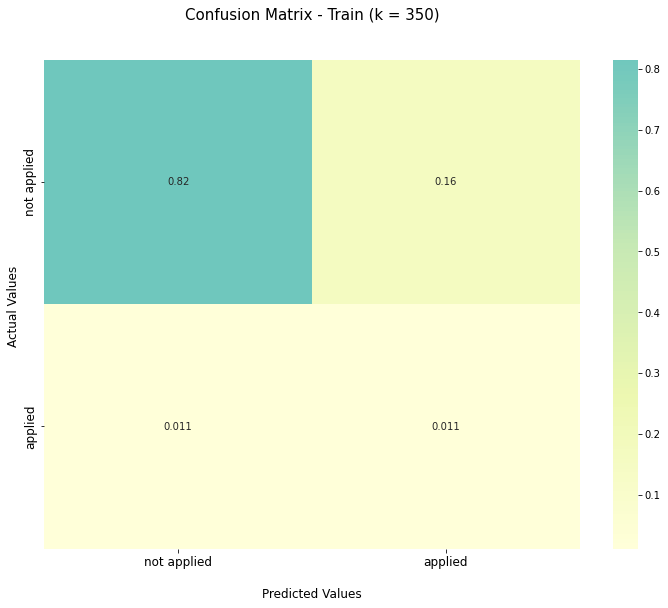

In [28]:
plot_confusion_matrix(df_class, 'Train (k = '+str(k)+')')

## Get Top N

In [ ]:
def get_top_n(df_pred, talentNo, n):
    '''Return the top N jobs that the user did not apply for'''
    
    # find the user's predictions
    df_user = df_pred.loc[(df_pred['talentNo'] == talentNo)]
    
    # the number of jobs that users have applied for
    cnt_applied = len(df_user.loc[(df_user['present']!=0)])
    
    # sort values by cnt_pred
    df_user = df_user.sort_values(by = 'predict', ascending = False)
    
    # remove the jobs that the user have already applied
    df_result = df_user.copy()
    df_result = df_result.loc[(df_result['present']==0)]
    df_result = df_result[:n]
    
    return df_result

In [ ]:
get_top_n(df_pred1_merge, 47985570, 1000)